# Quantum ESPRESSO on bulk silicon

This notebook is a compact introduction to a few basic technical points that are central in plane-wave DFT calculations with Quantum ESPRESSO:

1. how the choice of **unit cell** and **Brillouin-zone sampling** affects a calculation,
2. a **supercell at $\Gamma$** can be equivalent to a **smaller cell with a denser k-point mesh**,
3. how to compute and inspect a simple **band structure**,
4. how to test the convergence of a **derived quantity** with respect to k-point sampling.

The example system is **bulk silicon**. The notebook is intentionally simple and meant for exploration: students should change k-point meshes, lattice parameters, and cutoffs, and then compare the results.

---

## Suggested questions while working through the notebook

- How much does the total energy change when the k-point mesh is improved?
- Which comparison is fair: total energy of different cells, or **energy per equivalent cell**?
- Why increasing  lattice parameter bands become flat?
- How stable band gap when the k-point mesh changes?

## Imports and general setup

In [1]:
from pathlib import Path
import re
import shutil
import subprocess
import xml.etree.ElementTree as ET

import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import physical_constants, angstrom

from ase.build import bulk
from ase.io import read
import nglview as nv

## Helper functions

In [2]:
BOHR_TO_ANG = physical_constants["Bohr radius"][0] / angstrom
RY_TO_EV = 13.605693122994
HARTREE_TO_EV = 27.211386245988


def prepare_workspace(base_dir, task_names, clean=True):
    """Create task folders. If clean=True, remove old content first."""
    base_dir = Path(base_dir)
    for name in task_names:
        task_dir = base_dir / name
        if task_dir.exists() and clean:
            shutil.rmtree(task_dir)
        task_dir.mkdir(parents=True, exist_ok=True)


def show_structure(atoms, highlight=None):
    """Simple ASE/nglview visualizer."""
    widget = nv.NGLWidget(nv.ASEStructure(atoms))
    widget.add_unitcell()
    widget.add_ball_and_stick()
    widget.add_representation("label", labelType="atomindex", color="black")
    if highlight:
        widget.add_representation("spacefill", selection=highlight, color="blue", radius=0.5)
    return widget


def atoms_to_qe_strings(atoms):
    """Return CELL_PARAMETERS and ATOMIC_POSITIONS strings for QE."""
    cell = "\n".join(
        f"{v[0]:.10f} {v[1]:.10f} {v[2]:.10f}" for v in atoms.get_cell()
    )
    positions = "\n".join(
        f"{atom.symbol} {p[0]:.10f} {p[1]:.10f} {p[2]:.10f}"
        for atom, p in zip(atoms, atoms.get_scaled_positions())
    )
    return cell, positions


def parse_total_energy(qe_output):
    """Extract the last reported total energy in Ry from a QE output string."""
    match = re.findall(r"!\s+total energy\s+=\s+(-?\d+\.\d+)", qe_output)
    if not match:
        raise ValueError("Could not find a total energy in the QE output.")
    return float(match[-1])


def find_xml_file(workdir, prefix="mycalc"):
    """Locate the QE XML file in a robust way."""
    workdir = Path(workdir)
    candidates = [
        workdir / f"{prefix}.xml",
        workdir / f"{prefix}.save" / "data-file-schema.xml",
        workdir / f"{prefix}.save" / f"{prefix}.xml",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate

    fallback = list(workdir.glob("*.xml")) + list(workdir.glob(f"{prefix}.save/*.xml"))
    if fallback:
        return fallback[0]

    raise FileNotFoundError(f"No QE XML file found in {workdir}")


def read_qe_xml(xml_file):
    """
    Read basic data from a QE XML file.

    Returns a dictionary with:
    - kpts: k-points in the units written by QE
    - eigvals: KS eigenvalues in eV
    - fermi_en: Fermi energy in eV
    - rep_lat: reciprocal-lattice vectors
    """
    root = ET.parse(xml_file).getroot()
    output_node = root.find("output")
    band_node = output_node.find("band_structure")

    fermi_en = float(band_node.find("fermi_energy").text) * HARTREE_TO_EV

    kpts = []
    eigvals = []
    for kpt in band_node.findall("ks_energies"):
        kpts.append(np.array(kpt.find("k_point").text.split(), dtype=float))
        eigvals.append(np.array(kpt.find("eigenvalues").text.split(), dtype=float) * HARTREE_TO_EV)

    basis_set = output_node.find("basis_set")
    b1 = np.array(list(map(float, basis_set.find("reciprocal_lattice/b1").text.split())))
    b2 = np.array(list(map(float, basis_set.find("reciprocal_lattice/b2").text.split())))
    b3 = np.array(list(map(float, basis_set.find("reciprocal_lattice/b3").text.split())))

    return {
        "kpts": np.array(kpts),
        "eigvals": np.array(eigvals),
        "fermi_en": fermi_en,
        "rep_lat": np.array([b1, b2, b3]),
    }


def eigenvalues_at_kpoint(kpt_cryst, reciprocal_lattice, kpts, eigvals, atol=1e-3):
    """Return the eigenvalues at a chosen k-point written in crystal coordinates."""
    target = np.array(kpt_cryst) @ reciprocal_lattice
    mask = np.all(np.isclose(kpts, target, atol=atol), axis=1)
    indices = np.where(mask)[0]
    if len(indices) == 0:
        raise ValueError(f"K-point {kpt_cryst} not found in the XML data.")
    return eigvals[indices[0]]


def band_distances_and_ticks(path_labels, kpts, atol=1e-3):
    """Build the 1D coordinate along the path and the special-point ticks."""
    distances = [0.0]
    ticks = {path_labels[0]: 0.0}

    if len(kpts) < 2:
        return np.array(distances), ticks

    accumulated = 0.0
    previous_direction = kpts[1] - kpts[0]
    next_label_index = 1

    for i in range(1, len(kpts)):
        step = kpts[i] - kpts[i - 1]

        if not np.allclose(step, previous_direction, atol=atol):
            label = path_labels[next_label_index]
            if label in ticks:
                label = label + " "
            ticks[label] = accumulated
            next_label_index += 1

        accumulated += np.linalg.norm(step)
        distances.append(accumulated)
        previous_direction = step

    label = path_labels[next_label_index]
    if label in ticks:
        label = label + " "
    ticks[label] = accumulated

    return np.array(distances), ticks


def plot_bands(path_labels, kpts, eigvals, fermi_en, emin=-13, emax=4, title=None):
    """Simple band-structure plot referenced to the Fermi energy."""
    x, ticks = band_distances_and_ticks(path_labels, kpts)

    plt.figure(figsize=(6, 8))
    for band in (eigvals - fermi_en).T:
        plt.plot(x, band, lw=1.5, color="black")
    for xtick in ticks.values():
        plt.axvline(xtick, linewidth=0.8, color="black")
    plt.xticks(list(ticks.values()), list(ticks.keys()))
    plt.ylabel("Energy - $E_F$ [eV]")
    plt.ylim(emin, emax)
    plt.xlim(x.min(), x.max())
    if title:
        plt.title(title)
    plt.show()


def run_pw(pw_input_text, pw_exec, workdir, output_name="pw.out", live=False):
    """
    Run pw.x and return the full text output.
    The standard QE files are written inside workdir.
    """
    workdir = Path(workdir)
    workdir.mkdir(parents=True, exist_ok=True)

    input_file = workdir / "pw.in"
    output_file = workdir / output_name
    pw_exec = Path(pw_exec)

    if not pw_exec.exists():
        raise FileNotFoundError(f"QE executable not found: {pw_exec}")

    is_bands = "calculation = 'bands'" in pw_input_text or 'calculation = "bands"' in pw_input_text
    if not is_bands:
        (workdir / "mycalc.xml").unlink(missing_ok=True)
        shutil.rmtree(workdir / "mycalc.save", ignore_errors=True)

    input_file.write_text(pw_input_text)

    output_lines = []
    with output_file.open("w") as handle:
        process = subprocess.Popen(
            [str(pw_exec), "-in", str(input_file)],
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
        )

        for line in process.stdout:
            if live:
                print(line, end="")
            handle.write(line)
            output_lines.append(line)

        return_code = process.wait()

    if return_code != 0:
        raise RuntimeError(f"pw.x failed in {workdir}. Check {output_file}")

    return "".join(output_lines)


def pw_input(
    atoms,
    calculation,
    kpoints,
    workdir,
    ecutwfc,
    ecutrho,
    pseudo_file="Si.pbesol-n-rrkjus_psl.1.0.0.UPF",
    pseudo_dir=None,
):
    """Generate a minimal QE input for this silicon notebook."""
    cell, positions = atoms_to_qe_strings(atoms)

    kpoint_mode = "automatic"
    kpoint_block = kpoints

    if calculation == "bands":
        labels, npoints = kpoints.split()
        path = atoms.cell.bandpath(labels, npoints=int(npoints))
        kpoint_mode = "crystal"
        kpoint_block = str(len(path.kpts)) + "\n"
        kpoint_block += "\n".join(
            f"{k[0]:.8f} {k[1]:.8f} {k[2]:.8f} 1" for k in path.kpts
        )

    workdir = Path(workdir).resolve()
    pseudo_dir = Path(pseudo_dir if pseudo_dir is not None else workdir).resolve()

    return f"""&control
    calculation = '{calculation}'
    prefix = 'mycalc'
    pseudo_dir = '{pseudo_dir}/'
    outdir = '{workdir}/'
    verbosity = 'high'
/
&system
    ibrav = 0
    nat = {len(atoms)}
    ntyp = 1
    ecutwfc = {ecutwfc}
    ecutrho = {ecutrho}
    occupations = 'smearing'
    degauss = 0.001
/
&electrons
    conv_thr = 1.0d-8
    mixing_beta = 0.5
/
&ions
/
&cell
/
ATOMIC_SPECIES
Si 28.086 {pseudo_file}
ATOMIC_POSITIONS crystal
{positions}
K_POINTS {kpoint_mode}
{kpoint_block}
CELL_PARAMETERS angstrom
{cell}
"""


def estimate_si_gap(xml_data):
    """
    Approximate indirect gap for silicon using:
    - VBM at Gamma
    - CBM at X
    For simplicity we take the exact X point along GX.
    """
    rep_lat = xml_data["rep_lat"]
    eigvals = xml_data["eigvals"]
    kpts = xml_data["kpts"]

    eig_G = eigenvalues_at_kpoint([0.0, 0.0, 0.0], rep_lat, kpts, eigvals)
    eig_X = eigenvalues_at_kpoint([0.5, 0.0, 0.5], rep_lat, kpts, eigvals)

    vbm = eig_G[3]
    cbm = eig_X[4]
    return cbm - vbm

## Calculation settings

The notebook assumes that:

- `pw.x` is available in the environment shown below,
- the silicon pseudopotential file is in the same directory as the notebook,
- the cutoffs used here are sufficient for a teaching example, though not meant as a production-quality convergence study.

To keep the notebook robust even when calculations are run inside nested task subfolders, the pseudopotential directory is set using the absolute path of the notebook folder.


In [3]:
clean = True
current_dir = Path.cwd().absolute()
task_names = ["TASK_0", "TASK_0b", "TASK_0c", "TASK_2", "TASK_3", "TASK_4", "TASK_free", "TASK_relax"]

prepare_workspace(current_dir, task_names, clean=clean)

pw_exec = Path("/home/jovyan/.conda/envs/quantum-espresso-7.4/bin/pw.x")
pseudo_file = "Si.pbesol-n-rrkjus_psl.1.0.0.UPF"
pseudo_dir = current_dir.resolve()
pseudo_path = pseudo_dir / pseudo_file
if not pseudo_path.exists():
    raise FileNotFoundError(f"Pseudopotential not found: {pseudo_path}")

ecutwfc = 30
ecutrho = 240

print(f"Working directory: {current_dir}")
print(f"QE executable:    {pw_exec}")
print(f"Pseudopotential:  {pseudo_file}")
print(f"Pseudo dir:       {pseudo_dir}")
print(f"Cutoffs:          ecutwfc = {ecutwfc} Ry, ecutrho = {ecutrho} Ry")


Working directory: /home/jovyan/MMM_2025/Exercise_06
QE executable:    /home/jovyan/.conda/envs/quantum-espresso-7.4/bin/pw.x
Pseudopotential:  Si.pbesol-n-rrkjus_psl.1.0.0.UPF
Pseudo dir:       /home/jovyan/MMM_2025/Exercise_06
Cutoffs:          ecutwfc = 30 Ry, ecutrho = 240 Ry


## Task 0 — conventional cubic cell and the role of k-point sampling

We start from the **conventional cubic cell** of silicon (8 atoms).  
This is not the smallest possible cell, but it is visually convenient and easy to relate to the crystal structure.

We compare three SCF calculations:

- $\Gamma$ only,
- a non-shifted $2 \times 2 \times 2$ grid,
- a shifted $2 \times 2 \times 2$ grid.

The main point is not only the numerical value of the energy, but also **how quickly the result changes** when the Brillouin zone is sampled more carefully.

In [4]:
si_conv = bulk("Si", "diamond", a=5.43, cubic=True)
show_structure(si_conv)

NGLWidget()

In [5]:
scf_setups = [
    ("TASK_0",  "Gamma only",         "1 1 1 0 0 0"),
    ("TASK_0b", "2x2x2 unshifted",    "2 2 2 0 0 0"),
    ("TASK_0c", "2x2x2 shifted",      "2 2 2 1 1 1"),
]

scf_results = {}

for task_name, label, kmesh in scf_setups:
    workdir = current_dir / task_name
    pw_in = pw_input(si_conv, "scf", kmesh, workdir, ecutwfc, ecutrho, pseudo_file=pseudo_file, pseudo_dir=pseudo_dir)
    pw_out = run_pw(pw_in, pw_exec, workdir, output_name="pw.out", live=(label == "Gamma only"))
    scf_results[label] = {
        "kmesh": kmesh,
        "energy_ry": parse_total_energy(pw_out),
        "workdir": workdir,
    }


     Program PWSCF v.7.4 starts on 29Mar2026 at  8:59:45 

     This program is part of the open-source Quantum ESPRESSO suite
     for quantum simulation of materials; please cite
         "P. Giannozzi et al., J. Phys.:Condens. Matter 21 395502 (2009);
         "P. Giannozzi et al., J. Phys.:Condens. Matter 29 465901 (2017);
         "P. Giannozzi et al., J. Chem. Phys. 152 154105 (2020);
          URL http://www.quantum-espresso.org", 
     in publications or presentations arising from this work. More details at
     http://www.quantum-espresso.org/quote

     Parallel version (MPI & OpenMP), running on       8 processor cores
     Number of MPI processes:                 1
     Threads/MPI process:                     8

     MPI processes distributed on     1 nodes
     27968 MiB available memory on the printing compute node when the environment starts

     Reading input from /home/jovyan/MMM_2025/Exercise_06/TASK_0/pw.in

     Current dimensions of program PWSCF are:
     Max n


     Initial potential from superposition of free atoms

     starting charge      31.9957, renormalised to      32.0000
     Starting wfcs are   32 randomized atomic wfcs

     total cpu time spent up to now is        0.5 secs

     per-process dynamical memory:    47.7 Mb

     Self-consistent Calculation

     iteration #  1     ecut=    30.00 Ry     beta= 0.50
     Davidson diagonalization with overlap

---- Real-time Memory Report at c_bands before calling an iterative solver
           277 MiB given to the printing process from OS
            46 MiB allocation reported by mallinfo(arena+hblkhd)
         27869 MiB available memory on the node where the printing process lives
------------------
     ethr =  1.00E-02,  avg # of iterations =  3.0

     total cpu time spent up to now is        1.6 secs

     total energy              =     -89.92771193 Ry
     estimated scf accuracy    <       0.40677337 Ry

     iteration #  2     ecut=    30.00 Ry     beta= 0.50
     Davidson diago

In [6]:
reference_energy = scf_results["2x2x2 shifted"]["energy_ry"]

print("SCF energies for the conventional 8-atom cell\n")
for label, data in scf_results.items():
    delta_ev = (data["energy_ry"] - reference_energy) * RY_TO_EV
    print(
        f"{label:18s}  k = {data['kmesh']:15s}  "
        f"E = {data['energy_ry']: .10f} Ry   "
        f"ΔE = {delta_ev: .6f} eV"
    )

SCF energies for the conventional 8-atom cell

Gamma only          k = 1 1 1 0 0 0      E = -89.9372512800 Ry   ΔE =  9.839282 eV
2x2x2 unshifted     k = 2 2 2 0 0 0      E = -90.6447655100 Ry   ΔE =  0.213060 eV
2x2x2 shifted       k = 2 2 2 1 1 1      E = -90.6604251600 Ry   ΔE =  0.000000 eV


### Comment

A denser k-point mesh should improve the Brillouin-zone integration.  
For a periodic solid, comparing only a $\Gamma$-point calculation with a more complete mesh is often enough to show that **Brillouin-zone sampling matters even when the real-space structure is unchanged**.

## Task 2 — supercell at $\Gamma$ versus smaller cell with more k-points

Now we build a $2 \times 2 \times 2$ supercell of the same conventional cell and run it at $\Gamma$ only.

This is the key conceptual comparison:

- **smaller cell + denser k-point grid**, versus
- **larger real-space cell + fewer k-points**.

For commensurate choices, these can become equivalent descriptions of the same physics.

In [7]:
si_super = si_conv.repeat((2, 2, 2))
show_structure(si_super)

NGLWidget()

In [8]:
workdir = current_dir / "TASK_2"
pw_in = pw_input(si_super, "scf", "1 1 1 0 0 0", workdir, ecutwfc, ecutrho, pseudo_file=pseudo_file, pseudo_dir=pseudo_dir)
pw_out = run_pw(pw_in, pw_exec, workdir, output_name="pw.out")
energy_super_ry = parse_total_energy(pw_out)

energy_conv_unshifted_ry = scf_results["2x2x2 unshifted"]["energy_ry"]

print("Comparison of equivalent samplings\n")
print(f"Conventional cell, 2x2x2 unshifted mesh:  {energy_conv_unshifted_ry: .10f} Ry")
print(f"2x2x2 supercell at Gamma:                 {energy_super_ry: .10f} Ry total")
print(f"2x2x2 supercell at Gamma / 8:             {energy_super_ry / 8: .10f} Ry per conventional cell")

delta_equiv_ev = (energy_super_ry / 8 - energy_conv_unshifted_ry) * RY_TO_EV
print(f"Difference per conventional cell:         {delta_equiv_ev: .6e} eV")

Comparison of equivalent samplings

Conventional cell, 2x2x2 unshifted mesh:  -90.6447655100 Ry
2x2x2 supercell at Gamma:                 -725.1581241400 Ry total
2x2x2 supercell at Gamma / 8:             -90.6447655175 Ry per conventional cell
Difference per conventional cell:         -1.020428e-07 eV


The quantity to compare is **energy per equivalent cell**, not the raw total energy of systems with different numbers of atoms.

This is one of the most useful practical lessons in solid-state calculations:
changing the real-space cell also changes the Brillouin zone, so **real-space and reciprocal-space choices must always be interpreted together**.

## Task 3 — primitive cell and band structure

For the band structure it is more natural to use the **primitive cell** of silicon.

We first run a reasonably converged SCF calculation, then a `bands` calculation along the path

\[
L \rightarrow \Gamma \rightarrow X \rightarrow W \rightarrow L .
\]

This is not a complete high-symmetry path for all purposes, but it is enough for a teaching example.

In [9]:
si_prim = bulk("Si", "diamond", a=5.43)
show_structure(si_prim)

NGLWidget()

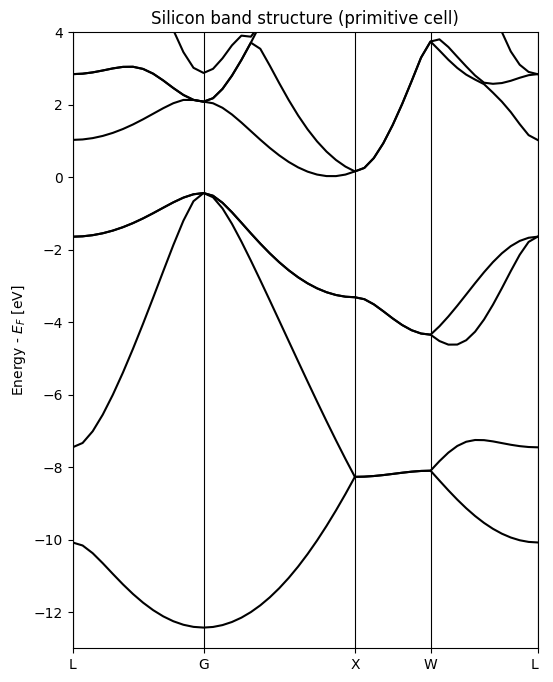

In [10]:
workdir = current_dir / "TASK_3"

pw_in = pw_input(si_prim, "scf", "5 5 5 1 1 1", workdir, ecutwfc, ecutrho, pseudo_file=pseudo_file, pseudo_dir=pseudo_dir)
_ = run_pw(pw_in, pw_exec, workdir, output_name="pw.out")

pw_in_bands = pw_input(si_prim, "bands", "LGXWL 50", workdir, ecutwfc, ecutrho, pseudo_file=pseudo_file, pseudo_dir=pseudo_dir)
_ = run_pw(pw_in_bands, pw_exec, workdir, output_name="bands.out")

xml_data_task3 = read_qe_xml(find_xml_file(workdir))
plot_bands("LGXWL", xml_data_task3["kpts"], xml_data_task3["eigvals"], xml_data_task3["fermi_en"], emin=-13, emax=4, title="Silicon band structure (primitive cell)")

## Task 4 — what changes if the lattice parameter is made unrealistically large?

Here we repeat the primitive-cell calculation with a very large lattice parameter.  
This is **not a physical model of silicon**. It is simply a useful numerical experiment.

The idea is to see how the bands evolve when the atoms are pushed far apart and the overlap between orbitals becomes very small.

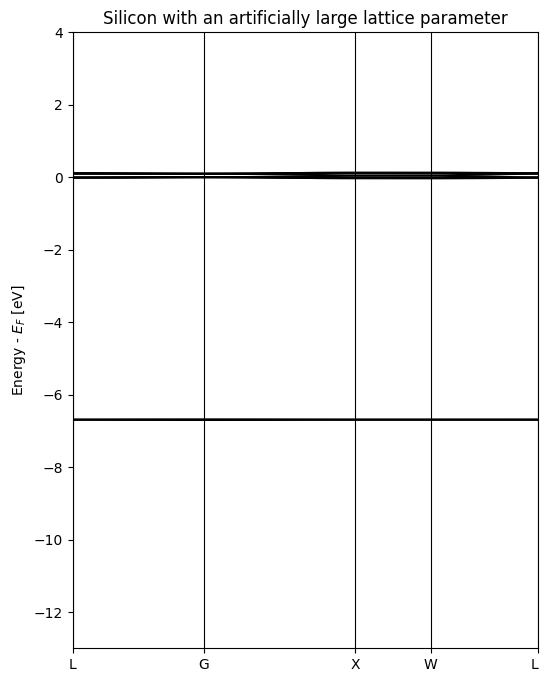

In [11]:
workdir = current_dir / "TASK_4"
si_prim_large = bulk("Si", "diamond", a=15.0)

pw_in = pw_input(si_prim_large, "scf", "2 2 2 1 1 1", workdir, ecutwfc, ecutrho, pseudo_file=pseudo_file, pseudo_dir=pseudo_dir)
_ = run_pw(pw_in, pw_exec, workdir, output_name="pw.out")

pw_in_bands = pw_input(si_prim_large, "bands", "LGXWL 50", workdir, ecutwfc, ecutrho, pseudo_file=pseudo_file, pseudo_dir=pseudo_dir)
_ = run_pw(pw_in_bands, pw_exec, workdir, output_name="bands.out")

xml_data_task4 = read_qe_xml(find_xml_file(workdir))
plot_bands("LGXWL", xml_data_task4["kpts"], xml_data_task4["eigvals"], xml_data_task4["fermi_en"], emin=-13, emax=4, title="Silicon with an artificially large lattice parameter")

## Convergence of a derived quantity: an approximate indirect gap

A total energy is not the only quantity that requires convergence checks.  
Here we estimate an indirect band gap in a simple way:

- valence-band maximum at $\Gamma$,
- conduction-band minimum at $X$.

For silicon this is only a teaching-level approximation, but it is very useful to show that **derived quantities can also depend strongly on the sampling choices**.

In [12]:
samplings = [
    ("1x1x1 Gamma",      "1 1 1 0 0 0"),
    ("2x2x2 unshifted",  "2 2 2 0 0 0"),
    ("2x2x2 shifted",    "2 2 2 1 1 1"),
    ("5x5x5 shifted",    "5 5 5 1 1 1"),
]

gap_results = []

for label, sampling in samplings:
    subdir = current_dir / "TASK_free" / label.replace(" ", "_")
    subdir.mkdir(parents=True, exist_ok=True)

    pw_in = pw_input(si_prim, "scf", sampling, subdir, ecutwfc, ecutrho, pseudo_file=pseudo_file, pseudo_dir=pseudo_dir)
    _ = run_pw(pw_in, pw_exec, subdir, output_name="pw.out")

    pw_in_bands = pw_input(si_prim, "bands", "GX 2", subdir, ecutwfc, ecutrho, pseudo_file=pseudo_file, pseudo_dir=pseudo_dir)
    _ = run_pw(pw_in_bands, pw_exec, subdir, output_name="bands.out")

    xml_data = read_qe_xml(find_xml_file(subdir))
    gap_results.append((label, estimate_si_gap(xml_data)))

In [13]:
print("Approximate indirect gap of Si from Gamma -> X\n")
for label, gap_ev in gap_results:
    print(f"{label:18s}  gap = {gap_ev: .6f} eV")

Approximate indirect gap of Si from Gamma -> X

1x1x1 Gamma         gap = -0.007666 eV
2x2x2 unshifted     gap =  0.445152 eV
2x2x2 shifted       gap =  0.577899 eV
5x5x5 shifted       gap =  0.597122 eV


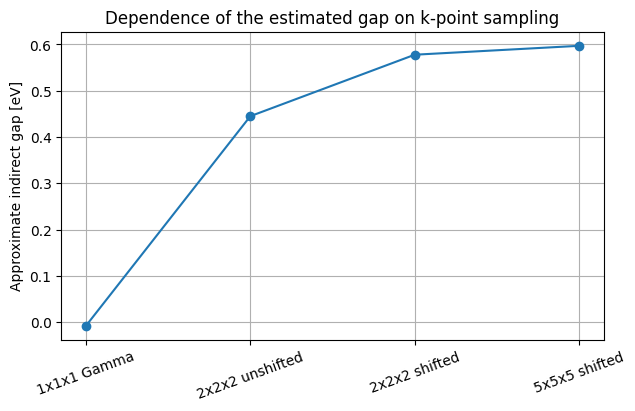

In [14]:
labels = [item[0] for item in gap_results]
gaps = [item[1] for item in gap_results]

plt.figure(figsize=(7, 4))
plt.plot(range(len(gaps)), gaps, marker="o")
plt.xticks(range(len(labels)), labels, rotation=20)
plt.ylabel("Approximate indirect gap [eV]")
plt.title("Dependence of the estimated gap on k-point sampling")
plt.grid(True)
plt.show()

## Optional example — variable-cell relaxation

This last part is optional.  
It shows how to launch a `vc-relax` calculation starting from the primitive silicon cell.

Because this is not the main point of the notebook, the calculation is disabled by default.  
Set `RUN_RELAX = True` if you want to execute it.

In [15]:
RUN_RELAX = False

if RUN_RELAX:
    workdir = current_dir / "TASK_relax"
    pw_in = pw_input(si_prim, "vc-relax", "5 5 5 1 1 1", workdir, ecutwfc, ecutrho, pseudo_file=pseudo_file, pseudo_dir=pseudo_dir)
    relax_out = run_pw(pw_in, pw_exec, workdir, output_name="pw.out", live=True)
    print("Relaxation finished.")
else:
    print("Relaxation not executed. Set RUN_RELAX = True to run it.")

Relaxation not executed. Set RUN_RELAX = True to run it.


### If a relaxation has been run, extract the final structure

In [16]:
relax_output = current_dir / "TASK_relax" / "pw.out"

if relax_output.exists():
    relaxed_atoms = read(relax_output, format="espresso-out")
    print(relaxed_atoms)
    show_structure(relaxed_atoms)
else:
    print("No relaxation output found yet.")

No relaxation output found yet.


## Possible extensions

A few natural follow-up exercises are:

1. change the **cutoffs** and check whether the energy ordering is affected,
2. compare **shifted** and **unshifted** meshes for other grid sizes,
3. repeat the supercell comparison with a different supercell size,
4. test whether the approximate gap is more sensitive to the **SCF mesh** or to the **band-path resolution**,
5. replace silicon with another elemental crystal and adapt pseudopotential and cutoffs.